# Analyse exploratoire du dataset Diamonds

## Importation des bibliothèques

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données

In [7]:
data = pd.read_csv(r'../data/diamonds.csv')


# Analyse globale et Contexte

In [8]:
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
data.shape

(53940, 11)

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [11]:
data[data.duplicated()]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


### Observations

Le dataset contient **53 940 observations et 11 colonnes**.

Chaque observation correspond à un diamant et décrit plusieurs caractéristiques liées à son poids, ses dimensions, sa qualité et son prix.

Aucune valeur manquante ni aucun doublon n'a été détecté.

Les variables peuvent être distinguées en deux groupes :

- **Variables numériques** : `carat`, `depth`, `table`, `price`, `x`, `y`, `z`
- **Variables catégorielles ordinales** : `cut`, `color`, `clarity`

Les valeurs des trois variables catégorielles sont attribuées selon les standards de l'Industrie du diamands possédant un ordre métier qui devra être pris en compte lors de l'analyse.

**Descriptions des variables**

| Variable  | Type                  | Description                  |
| --------- | --------------------- | ---------------------------- |
| `price`   | Numérique             | Prix du diamant en dollars   |
| `carat`   | Numérique             | Poids du diamant             |
| `cut`     | Catégorielle ordinale | Qualité de la taille         |
| `color`   | Catégorielle ordinale | Qualité de la couleur        |
| `clarity` | Catégorielle ordinale | Pureté du diamant            |
| `depth`   | Numérique             | Profondeur totale du diamant |
| `table`   | Numérique             | Largeur de la table          |
| `x`       | Numérique             | Longueur en mm               |
| `y`       | Numérique             | Largeur en mm                |
| `z`       | Numérique             | Profondeur en mm             |


## Distribution des variables catégorielles

`cut`

| Rang | Valeur        | Signification métier                            |
| ---- | ------------- | ----------------------------------------------- |
| 1    | **Ideal**     | Taille parfaite, meilleure réflexion de lumière |
| 2    | **Premium**   | Excellente taille                               |
| 3    | **Very Good** | Très bonne taille                               |
| 4    | **Good**      | Bonne taille                                    |
| 5    | **Fair**      | Qualité correcte mais moins performante         |


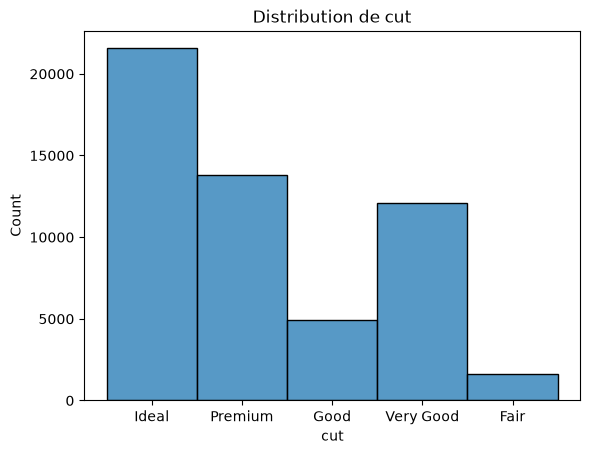

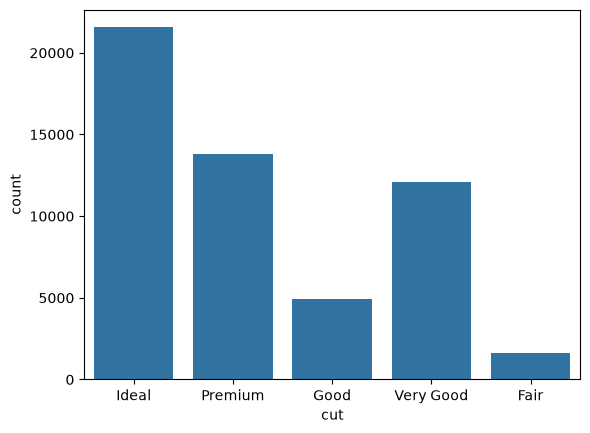

In [12]:
sns.histplot(data['cut'])
plt.title('Distribution de cut')
plt.show()

sns.countplot(data=data,x='cut')
plt.show()

In [13]:
data['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

La modalité `Ideal` est la plus représentée avec **21 551 observations**, tandis que `Fair` est la moins représentée avec **1 610 observations**.

La distribution des modalités est donc déséquilibrée : les catégories correspondant aux meilleures qualités de taille sont davantage représentées dans cet échantillon.

Cette répartition devra être conservée en mémoire lors des analyses ultérieures, notamment lorsque l'on comparera le prix entre les différentes catégories.

In [14]:
#data['cut'] = data['cut'].replace('Fair', 'Good')
#data['cut'].value_counts()

`color`

description des variables - 
| Rang | Valeur | Signification métier                          |
| ---- | ------ | --------------------------------------------- |
|  1   | **D**  | Colorless — aucune couleur visible (meilleur) |
| 2    | **E**  | Colorless — quasi parfait                     |
| 3    | **F**  | Colorless — excellente qualité                |
| 4    | **G**  | Near Colorless — très légère teinte           |
| 5    | **H**  | Near Colorless — légère teinte                |
| 6    | **I**  | Near Colorless — teinte légèrement visible    |
| 7    | **J**  | Near Colorless — plus jaune (moins bon)       |


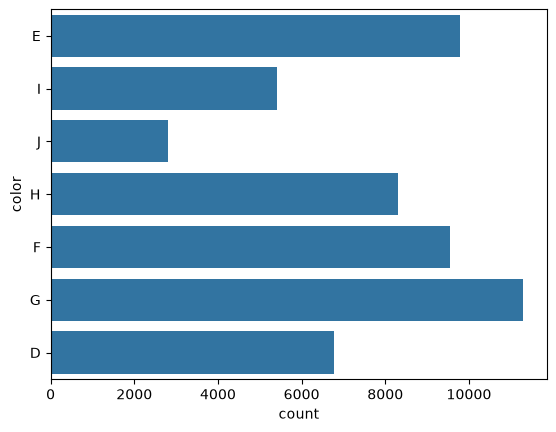

In [15]:
sns.countplot(data['color'])
plt.show()

In [16]:
data['color'].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

La modalité `G` est la plus représentée avec 11 292 observations.

À l'inverse, `J` est la moins représentée avec 2 808 observations.

Les catégories ne sont donc pas réparties uniformément dans l'échantillon.

On observe également que les catégories intermédiaires sont davantage représentées que les catégories situées aux extrêmes de l'échelle de couleur.

`clarity`\
description des variables:

| Rang | Valeur   | Signification métier                                |
| ---- | -------- | --------------------------------------------------- |
| 1    | **IF**   | Internally Flawless — aucune inclusion interne      |
| 2    | **VVS1** | Très très petites inclusions (difficiles à voir)    |
| 3    | **VVS2** | Très très petites inclusions (un peu plus visibles) |
| 4    | **VS1**  | Très petites inclusions                             |
| 5    | **VS2**  | Très petites inclusions légèrement plus visibles    |
| 6    | **SI1**  | Petites inclusions visibles à la loupe              |
| 7    | **SI2**  | Petites inclusions plus importantes                 |
| 8    | **I1**   | Inclusions visibles                                 |
| 9    | **I2**   | Inclusions nombreuses et visibles                   |
| 10   | **I3**   | Très nombreuses inclusions (moins bonne qualité)    |


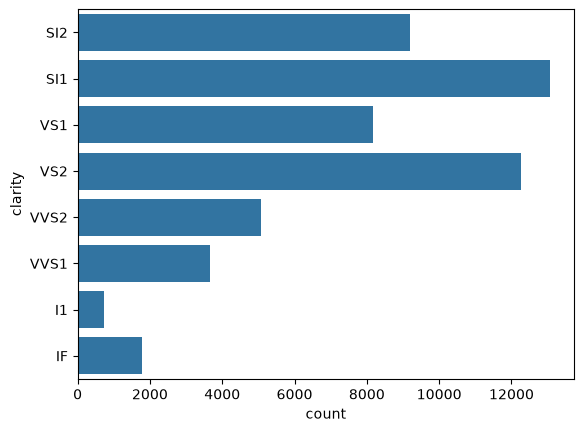

In [17]:
sns.countplot(data['clarity'])
plt.show()

In [18]:
data['clarity'].value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

Les modalités `SI1` et `VS2` sont les plus représentées avec respectivement 13 065 et 12 258 observations.

À l'inverse, `I1` et `IF` sont les moins représentées avec respectivement 741 et 1 790 observations.

La distribution est donc fortement concentrée sur certaines catégories intermédiaires.

## Synthèse de l'analyse des variables catégorielles

L'analyse des variables `cut`, `color` et `clarity` montre que leurs modalités ne sont pas réparties uniformément dans le dataset.

Certaines catégories sont fortement représentées, tandis que d'autres sont minoritaires. Cette observation est particulièrement importante pour la suite de l'analyse : les différences observées entre catégories devront être interprétées en tenant compte du nombre d'observations disponibles dans chacune d'elles.

Aucune modalité ne sera supprimée ou fusionnée à ce stade, car leur faible représentation constitue une caractéristique du dataset et non, à elle seule, un problème de qualité des données.

## Variable numérique
La prochaine étape consistera à analyser les variables numériques et leurs distributions.

In [19]:
# Colonne d'index chargés par erreur à supprimer
data = data.drop(columns='Unnamed: 0')

In [20]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Comparaison moyenne/ médiane
**Permets de révéler l'influence de valeurs extrêmes sur la moyenne** 
Pour la majorité des variables, la moyenne et la médiane sont relativement proches. En revanche, `Price` présente une différence importante entre ces deux indicateurs, d'environ 1 500 $.

Cette différence suggère que la distribution des prix est asymétrique et que des valeurs élevées peuvent tirer la moyenne vers le haut.

### Comparaison 3ème quartile /max
Permet de repérer si certaines valeurs maximales sont particulièrement éloignées de la majorité des observations.

On observe une différence importante entre Q3 et le maximum pour l'ensemble des variables numériques. Cela peut suggérer la présence de valeurs extrêmes, qui devront être étudiées plus précisément à l'aide de visualisations et de méthodes statistiques adaptées.

### Valeurs minimales aberrantes pour `x`, `y` et `z`
Pour les trois variables `x`, `y` et `z`, on observe des valeurs minimales incohérentes avec les dimensions réelles d'un diamant. Ces valeurs méritent donc d'être vérifiées et potentiellement traitées lors du nettoyage des données.


## Distribution


In [21]:
num = data[['carat','depth','table','price','x','y','z']]
num

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74


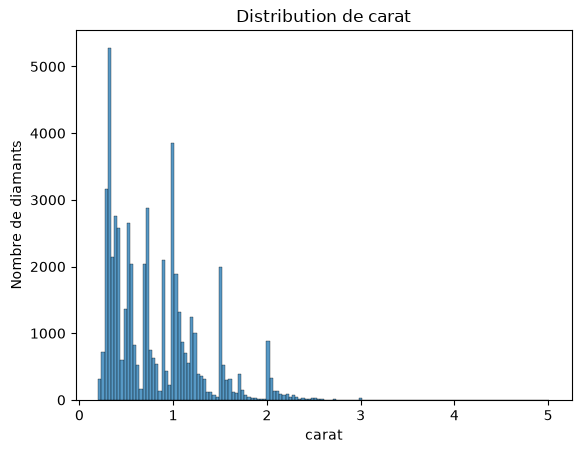

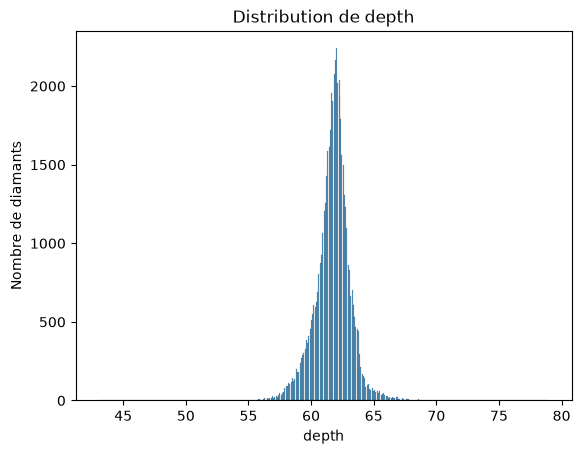

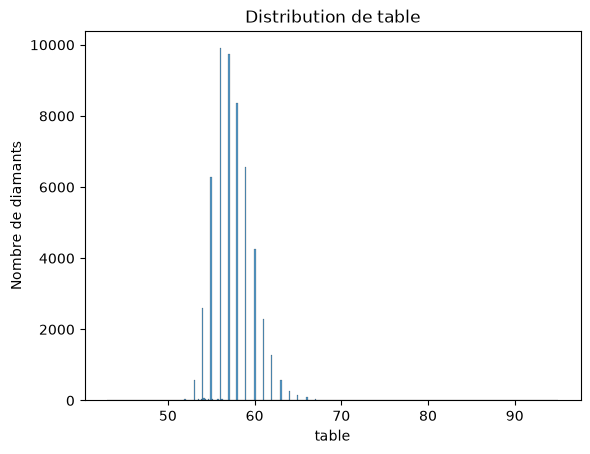

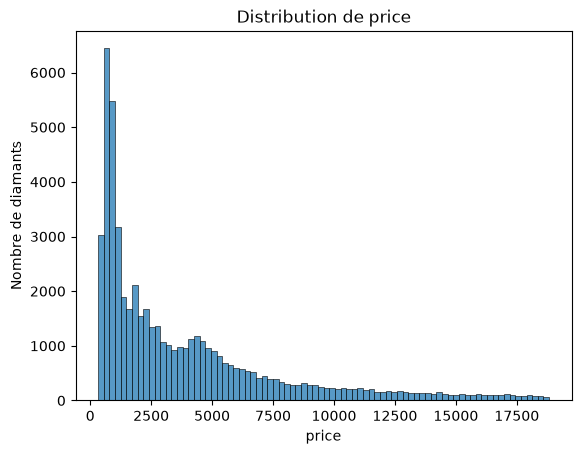

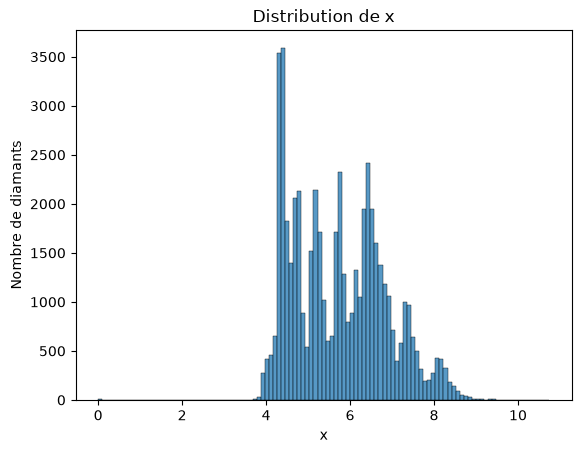

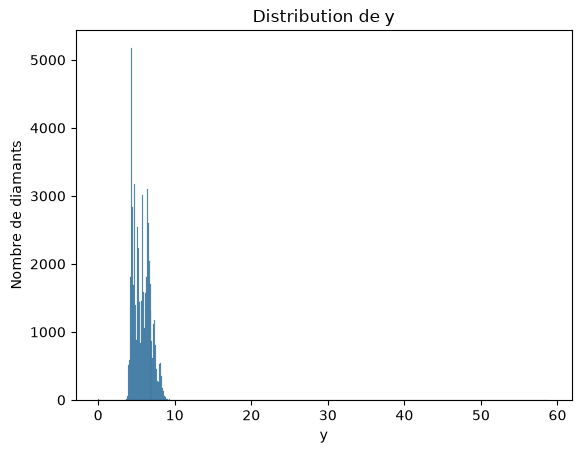

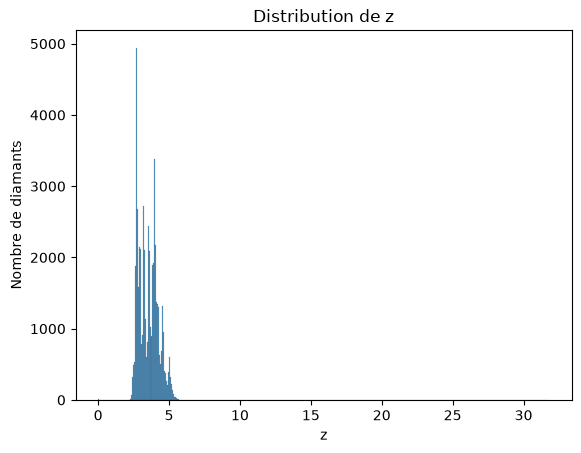

In [22]:
for i in num.columns:
    sns.histplot(data[i])
    plt.title(f'Distribution de {i}')
    plt.xlabel(i)
    plt.ylabel('Nombre de diamants')
    plt.show()

### Observation

Les histogrammes montrent que les variables n'ont pas toutes la même distribution.

`carat` et `price` sont assez **asymétriques vers la droite** : la majorité des valeurs est concentrée dans les faibles ou moyennes valeurs, avec quelques observations beaucoup plus élevées. Cette asymétrie est particulièrement visible pour `price`.

À l'inverse, `depth` et `table` sont davantage **concentrées autour d'une valeur centrale** et présentent une dispersion plus faible.

Pour `x`, `y` et `z`, on observe également une **asymétrie vers la droite**, ainsi que quelques valeurs qui semblent atypiques. Les valeurs égales à 0 pour ces trois variables sont notamment à vérifier, car elles ne semblent pas cohérentes avec les dimensions réelles d'un diamant.

Ces premières observations montrent donc qu'il faudra porter une attention particulière aux **valeurs aberrantes et aux valeurs nulles** lors du nettoyage des données.

## Analyse de la variable `Price`


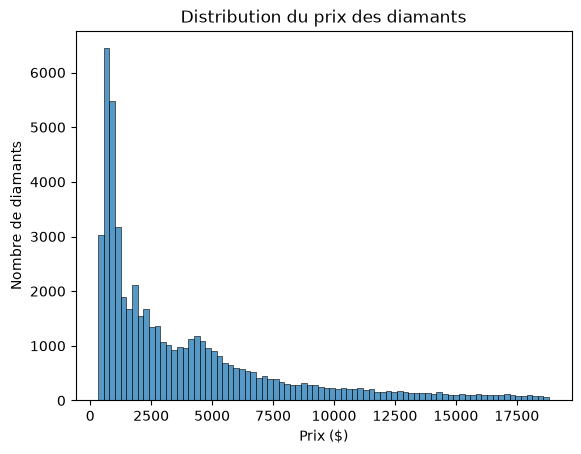

In [23]:
sns.histplot(data['price'])
plt.title('Distribution du prix des diamants')
plt.xlabel('Prix ($)')
plt.ylabel('Nombre de diamants')
plt.show()

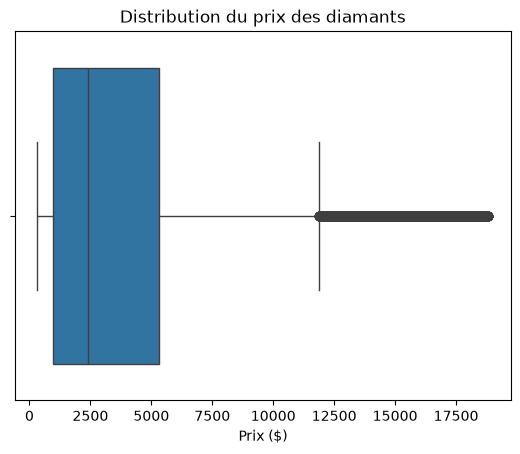

In [24]:
sns.boxplot(x=data['price'])
plt.title('Distribution du prix des diamants')
plt.xlabel('Prix ($)')
plt.show()

## Analyse de la variable `price`

### Statistiques descriptives

Le prix des diamants varie de **326 $ à 18 823 $**, avec une médiane de **2 401 $**.

La différence importante entre la moyenne et la médiane indique que les prix élevés peuvent tirer la moyenne vers le haut. La médiane est donc plus représentative du prix d'un diamant « typique » dans ce dataset.

### Distribution de `price`

L'histogramme montre une **forte asymétrie vers la droite** : la majorité des diamants ont un prix relativement faible ou moyen, tandis qu'un nombre plus limité de diamants présente des prix très élevés.

Cette distribution confirme l'observation faite lors de la comparaison entre la moyenne et la médiane.

### Valeurs extrêmes

La comparaison entre le troisième quartile (Q3) et le maximum montre que certaines valeurs sont particulièrement éloignées de la majorité des observations.

Le boxplot permet de visualiser plus précisément ces valeurs et d'identifier les observations potentiellement aberrantes.

Ces valeurs élevées ne sont cependant pas nécessairement des erreurs : elles peuvent correspondre à des diamants ayant des caractéristiques particulières. Il faudra donc chercher à comprendre leur origine avant d'envisager de les supprimer.

### Questions pour la suite

Cette analyse de `price` soulève plusieurs questions :

* Quelles caractéristiques sont associées aux prix élevés ?
* Le poids du diamant (`carat`) est-il fortement lié au prix ?
* La qualité (`cut`, `color`, `clarity`) influence-t-elle également le prix ?
* Quelle variable semble avoir la relation la plus forte avec `price` ?

## Relation entre les variables et le prix



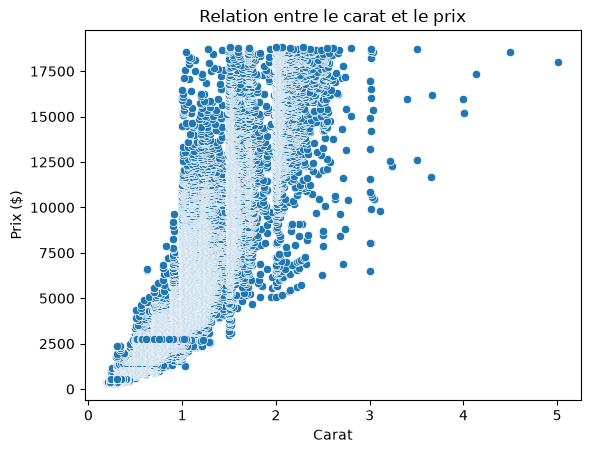

In [25]:
sns.scatterplot(data=data, x='carat', y='price')
plt.title('Relation entre le carat et le prix')
plt.xlabel('Carat')
plt.ylabel('Prix ($)')
plt.show()

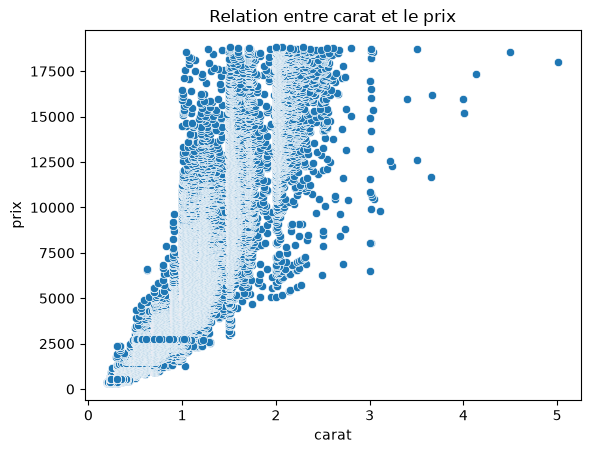

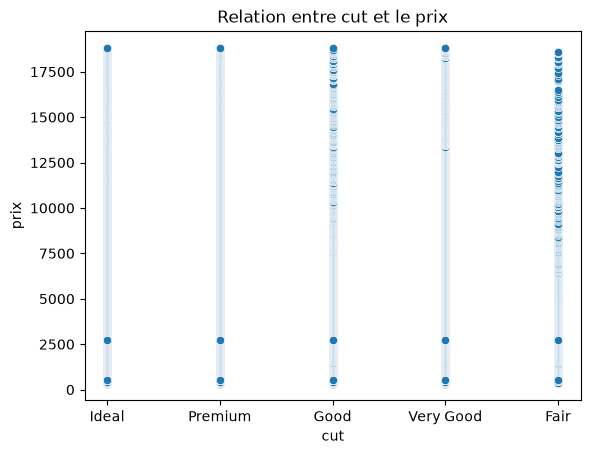

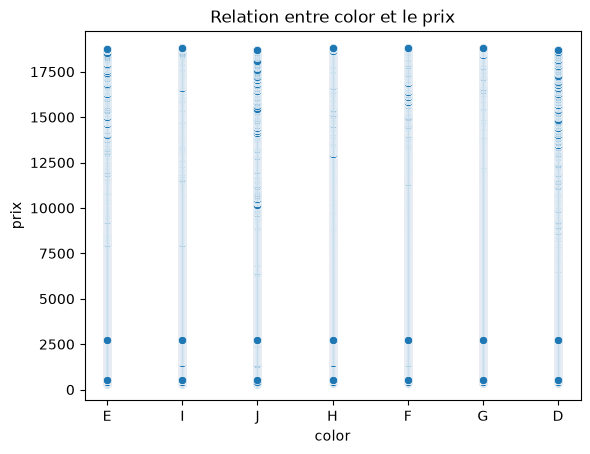

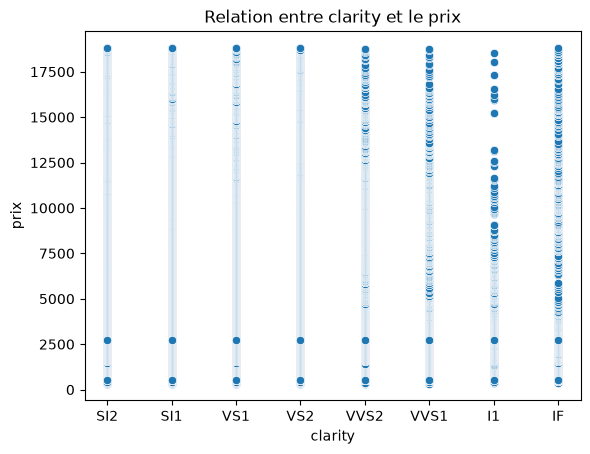

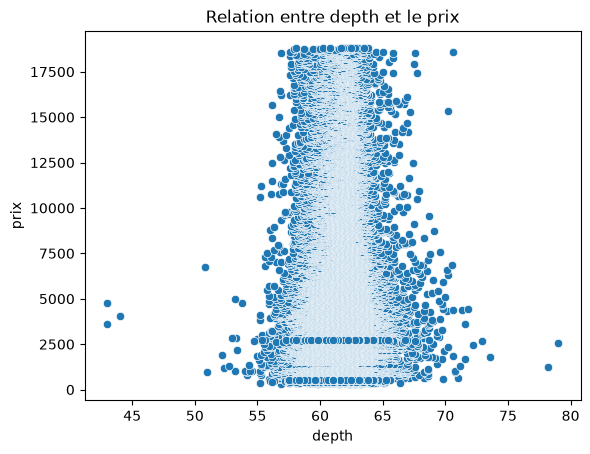

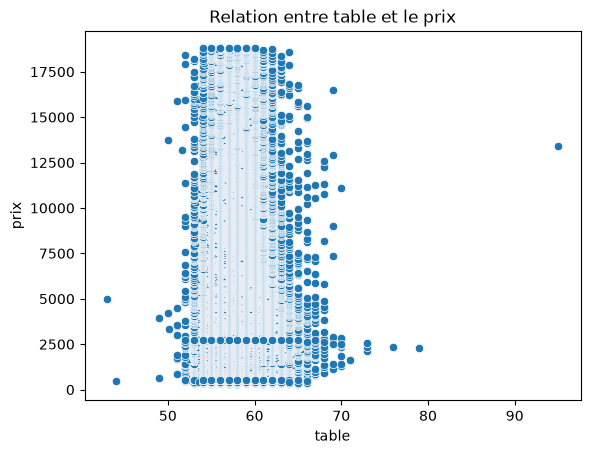

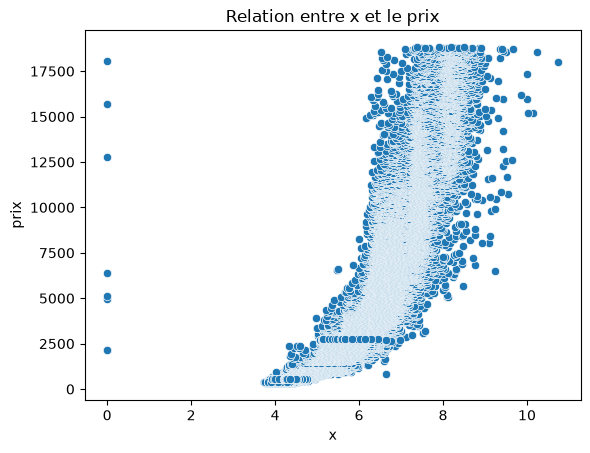

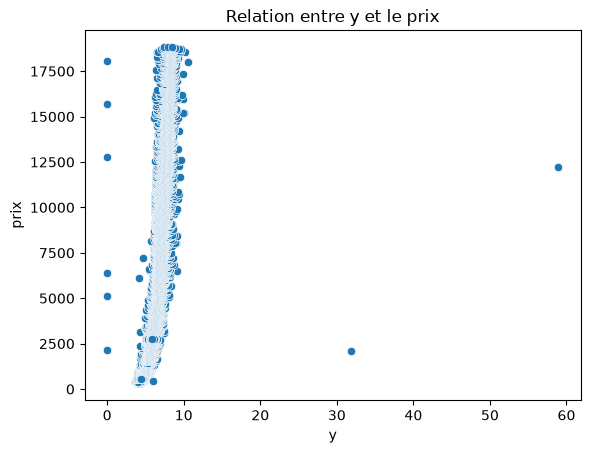

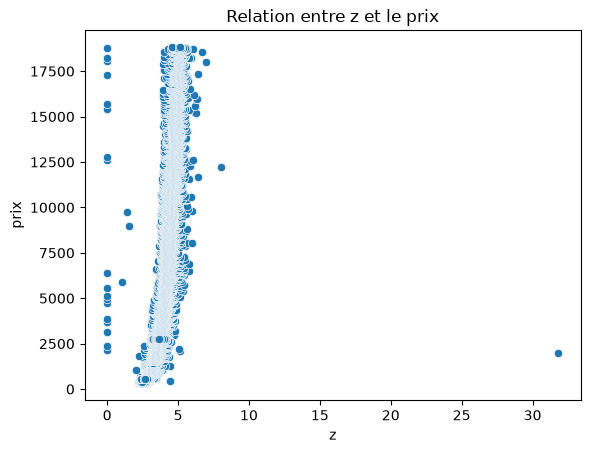

In [26]:
for x in data.columns.drop('price'):
    sns.scatterplot(data=data, x=x, y='price')
    plt.title(f'Relation entre {x} et le prix')
    plt.xlabel(f'{x}')
    plt.ylabel('prix')
    plt.show()

### Observations

**Carat – Prix**
On observe une relation positive entre le carat et le prix, surtout pour les diamants de petite taille : jusqu'à environ 1 carat, le prix augmente assez nettement avec le carat. Au-delà, la relation devient moins claire et les prix sont beaucoup plus dispersés. Pour les diamants de plus de 3 carats, les prix sont généralement élevés, mais restent très variables.

**Cut – Prix**
La qualité de la coupe semble avoir une certaine relation avec le prix, notamment pour les coupes de moins bonne qualité. Cependant, une meilleure qualité de coupe ne signifie pas forcément un prix plus élevé. Les différentes catégories présentent des prix assez dispersés.

**Color – Prix**
La distribution des prix est relativement homogène entre les différentes catégories de couleur. La couleur ne semble donc pas avoir une relation très marquée avec le prix dans ce graphique.

**Clarity – Prix**
Les diamants ayant une faible qualité de clarté semblent avoir tendance à être moins chers. Cependant, une bonne clarté ne garantit pas un prix élevé : les prix restent assez dispersés au sein des meilleures catégories.

**Depth – Prix**
La relation entre la profondeur et le prix semble assez faible. Les valeurs sont relativement homogènes et, même autour de la profondeur moyenne située entre 60 et 65 %, les prix restent très dispersés, avec quelques valeurs plus élevées.

**Table – Prix**
On observe une tendance similaire à celle de `depth`. La relation avec le prix semble faible et les valeurs sont relativement dispersées. Il est donc difficile d'identifier une relation claire entre la table et le prix.

**X – Prix**
On observe une tendance positive assez nette : lorsque la dimension `x` augmente, le prix a tendance à augmenter également.

**Y et Z – Prix**
Les variables `y` et `z` présentent également une tendance positive avec le prix. Plus les dimensions du diamant augmentent, plus le prix a tendance à être élevé.

### synthèse

Les variables `carat`, `x` , `y` et `z` montrent les relations positives les plus évidentes avec le prix.
À l'inverse, `depth` et `table` ne semblent pas présenter de relation claire avec le prix. Les variables catégorielles `cut`, `color` et `clarity` montrent des différences entre leurs catégories, mais les distributions se chevauchent fortement.

Les variables `x`, `y` et `z` devront cependant être interprétées avec le carat, car elles décrivent des caractéristiques liées à la taille du diamant.

## Relation des variables `x`, `y` et `z` avec `carat`

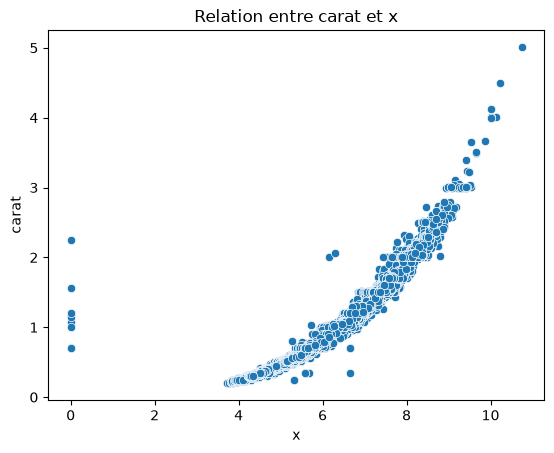

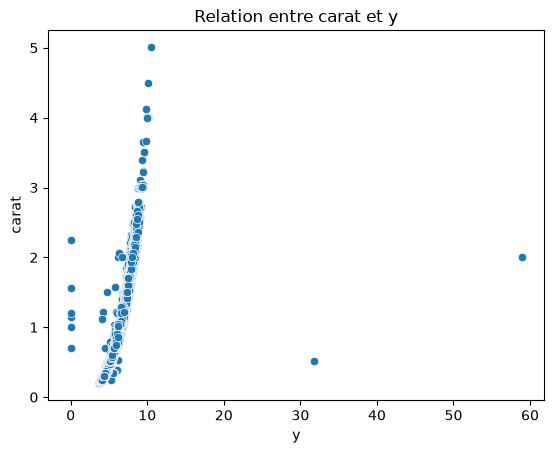

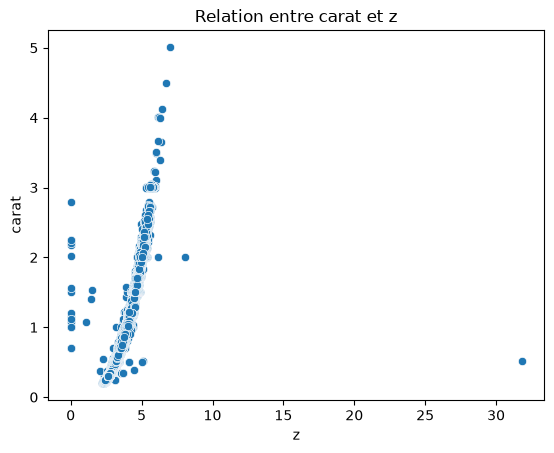

In [27]:
variable = data[['x','y','z', 'carat']]

for x in variable.columns.drop('carat'):
    sns.scatterplot(data=variable,x=x, y='carat')
    plt.title(f'Relation entre carat et {x}')
    plt.xlabel(f'{x}')
    plt.ylabel('carat')
    plt.show()

### Observation 
Les relations entre le `carat` et les dimensions `x`, `y` et `z` sont **positives et assez homogènes**. On observe cependant quelques **valeurs atypiques** qui s'éloignent de la tendance générale. Ces points peuvent correspondre à des diamants présentant des proportions particulières ou à d'éventuelles erreurs dans les données. Ils seront à examiner plus en détail avant de décider s'ils doivent être conservés ou supprimés.

## Corrélation

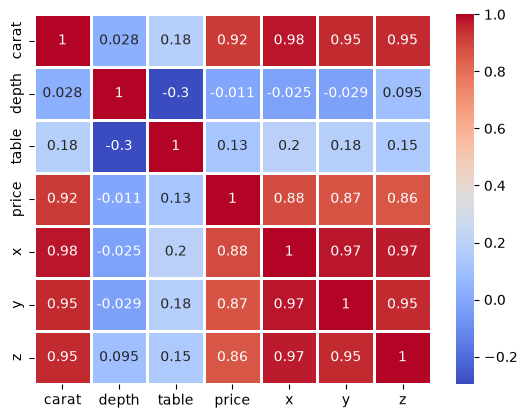

In [28]:
corr = data.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', annot=True, linewidth=0.9)
plt.show()

### Analyse de la corrélation

La matrice de corrélation confirme les observations faites lors de l'analyse bivariée.

On observe une **très forte corrélation positive entre `x`, `y` et `z`**, ce qui est logique puisque ces trois variables correspondent aux dimensions du diamant.

Le **`carat` présente également une très forte corrélation avec `x`, `y` et `z` (environ 97 %)**. Cela confirme que ces variables sont fortement liées à la taille du diamant.

Concernant le prix, le **`carat` présente la plus forte corrélation avec `price`**, suivi par `x`, `y` et `z`. Cependant, ces variables étant elles-mêmes fortement corrélées entre elles, il faut garder à l'esprit qu'elles apportent en partie une information similaire.

Les résultats confirment donc que la **taille du diamant est fortement associée à son prix**, tandis que `depth` et `table` présentent une relation beaucoup plus faible avec celui-ci.


# Cleaning
### Valeurs nulles de x, y et z 
Les valeurs égales à 0 sont incohérente (un diamands ne peut pas avoir un poids, une taille ou une dimension égale à 0). Elle seront donc supprimer

In [29]:
data = data[(data['x']!=0)&(data['y']!=0)&(data['z']!=0)]


In [30]:
data[(data['x']==0)&(data['y']==0)&(data['z']==0)]

,carat,cut,color,clarity,depth,table,price,x,y,z


In [31]:
# Colonne d'index chargés par erreur à supprimer
#data = data.drop(columns='Unnamed: 0')

In [32]:
data.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


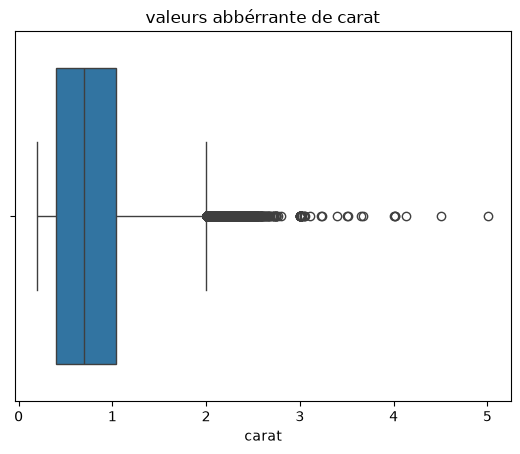

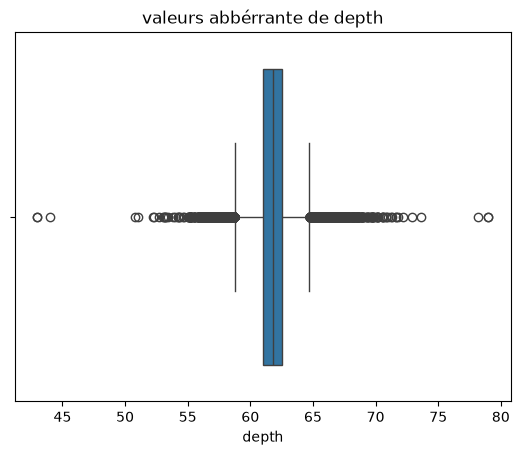

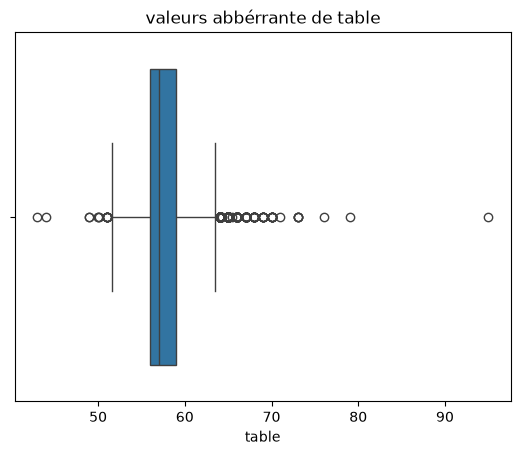

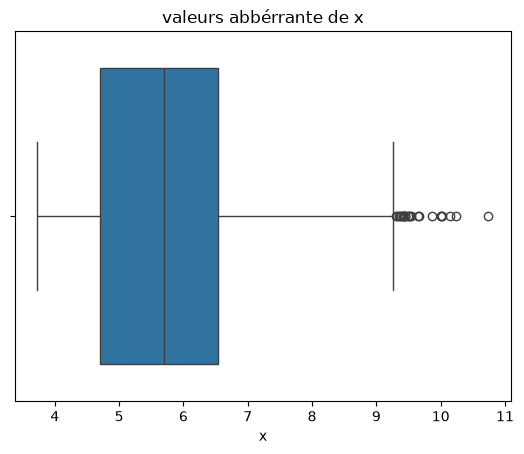

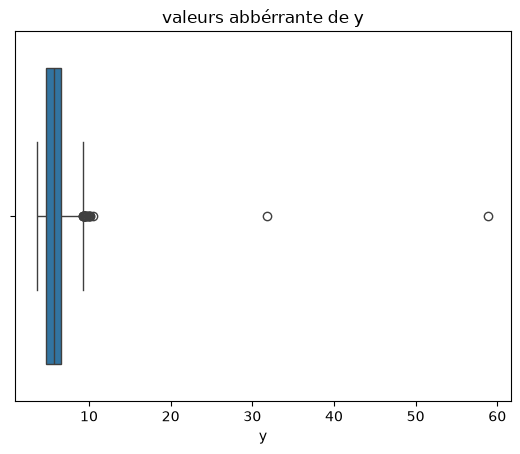

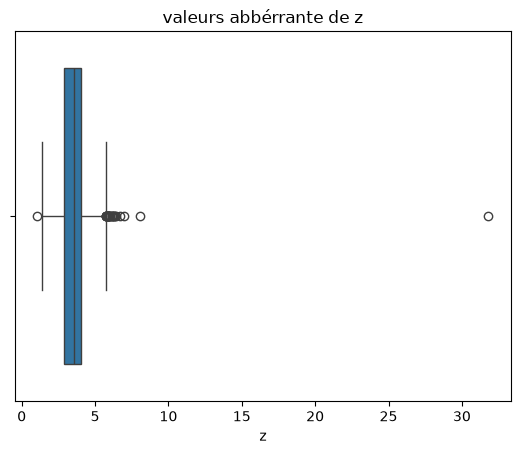

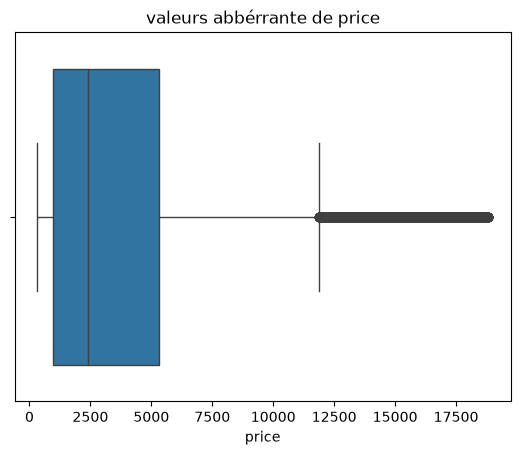

In [33]:
variable = data[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']]


for x in variable.columns:
    sns.boxplot(data=variable, x=x)
    plt.title(f'valeurs abbérrante de {x}')
    plt.show()

### Analyse des valeurs aberrantes

Les boxplots mettent en évidence des valeurs atypiques pour plusieurs variables.

Pour **`depth`** et **`table`**, on observe des valeurs aberrantes aux **deux extrémités** de la distribution.

Pour les autres variables (`carat`, `x`, `y`, `z` et `price`), les valeurs atypiques se situent principalement dans les **valeurs élevées**. La variable **`price`** présente notamment un grand nombre de valeurs extrêmes, ce qui peut s'expliquer par la forte dispersion des prix et la présence de diamants particulièrement chers.

Ces valeurs atypiques ne sont pas nécessairement des erreurs. Elles devront être examinées afin de déterminer si elles correspondent à des observations réelles ou à des incohérences dans les données.

## Outliers


In [34]:
Q1 = data['carat'].quantile(0.25)
Q3 = data['carat'].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = data[
    (data['carat'] < borne_inf) |
    (data['carat'] > borne_sup)]


In [35]:
outliers.sort_values('price', ascending=True).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
12246,2.06,Premium,J,I1,61.2,58.0,5203,8.10,8.07,4.95
13002,2.14,Fair,J,I1,69.4,57.0,5405,7.74,7.70,5.36
13118,2.15,Fair,J,I1,65.5,57.0,5430,8.01,7.95,5.23
13757,2.22,Fair,J,I1,66.7,56.0,5607,8.04,8.02,5.36
13991,2.01,Fair,I,I1,67.4,58.0,5696,7.71,7.64,5.17
13992,2.01,Fair,I,I1,55.9,64.0,5696,8.48,8.39,4.71
14138,2.27,Fair,J,I1,67.6,55.0,5733,8.05,8.00,5.43
14912,2.03,Fair,H,I1,64.4,59.0,6002,7.91,7.85,5.07
14913,2.03,Fair,H,I1,66.6,57.0,6002,7.81,7.75,5.19
15151,2.06,Good,H,I1,64.3,58.0,6091,8.03,7.99,5.15


In [36]:
outliers.shape

(1883, 10)

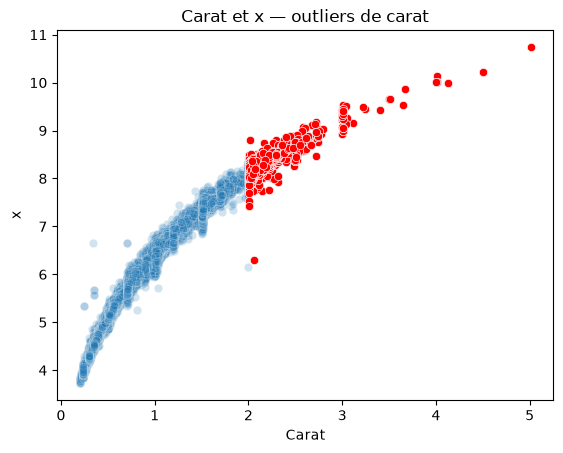

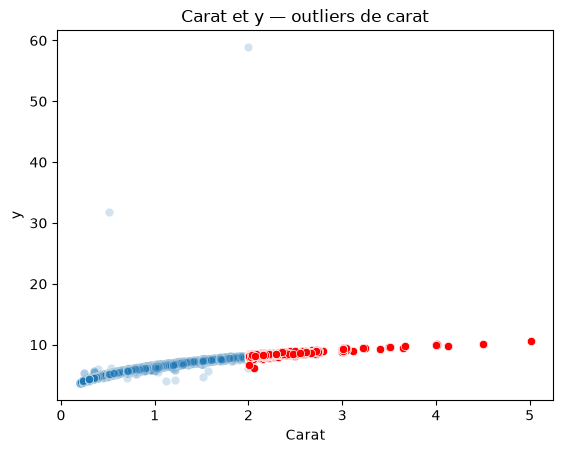

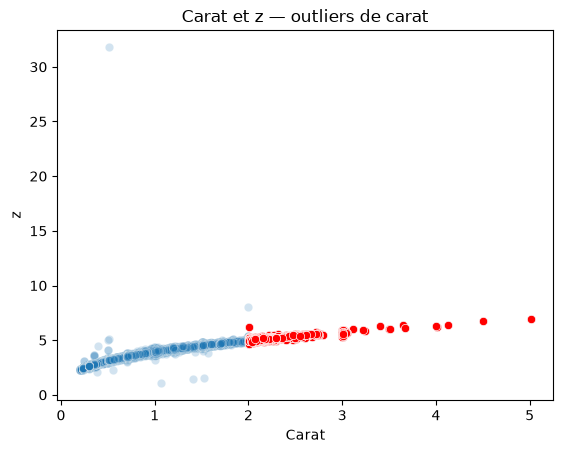

In [38]:
variables = ['x', 'y', 'z']

for var in variables:
    sns.scatterplot(data=data, x='carat', y=var, alpha=0.2)
    sns.scatterplot(data=outliers, x='carat', y=var, color='red')
    
    plt.title(f'Carat et {var} — outliers de carat')
    plt.xlabel('Carat')
    plt.ylabel(var)
    plt.show()

### Observation
Les valeurs élevées de carat sont associées à des valeurs élevées de price, x, y et z. Ces valeurs sont donc atypiques d'un point de vue statistique, mais restent cohérentes avec les autres caractéristiques des diamants. Elles ne semblent pas correspondre à des erreurs de données et sont donc conservées.

# Analyse Métier 
### Problématique
**Quels facteurs sont associés au prix d'un diamant, et comment les caractéristiques du diamant permettent-elles d'expliquer les différences de prix ?**
## Facteur principal: `carat`

In [ ]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
data['carat_group'] = pd.cut(
    data['carat'],
    bins=[0, 0.5, 1, 1.5, 2, 3, data['carat'].max()],
    labels=['0-0.5', '0.5-1', '1-1.5', '1.5-2', '2-3', '3+']
)

In [ ]:
group = data[['carat_group', 'cut', 'color', 'clarity', 'price']]
group

,carat_group,cut,color,clarity,price
0,0-0.5,Ideal,E,SI2,326
1,0-0.5,Premium,E,SI1,326
2,0-0.5,Good,E,VS1,327
3,0-0.5,Premium,I,VS2,334
4,0-0.5,Good,J,SI2,335
...,...,...,...,...,...
53935,0.5-1,Ideal,D,SI1,2757
53936,0.5-1,Good,D,SI1,2757
53937,0.5-1,Very Good,D,SI1,2757
53938,0.5-1,Premium,H,SI2,2757


In [ ]:
data.groupby(
    ['carat_group', 'cut'],
    observed=True
)['price'].mean().unstack()

cut,Fair,Good,Ideal,Premium,Very Good
carat_group,,,,,
0-0.5,1027.979275,786.054191,863.908535,863.329085,766.354590
0.5-1,2802.109661,3060.233900,2596.377115,2901.666845,2958.121318
1-1.5,4999.901299,5897.766697,7056.145596,6260.796619,6502.438532
1.5-2,9058.804054,10518.217666,11866.778404,11261.136364,11430.864583
2-3,11697.037383,14535.402439,15599.042644,14983.711724,15130.266839
3+,14915.500000,18359.000000,14426.750000,14961.461538,15669.000000


In [ ]:
data.groupby(
    ['carat_group', 'cut'],
    observed=True
)['price'].median().unstack()

cut,Fair,Good,Ideal,Premium,Very Good
carat_group,,,,,
0-0.5,1002.0,685.0,825.0,827.0,684.0
0.5-1,2596.0,2819.0,2353.0,2578.5,2652.0
1-1.5,4538.0,5233.0,6467.0,5648.0,5839.0
1.5-2,8621.0,9791.0,11531.0,11034.5,11068.5
2-3,12592.0,14928.0,15990.0,15238.0,15679.5
3+,16646.5,18242.0,14312.0,15223.0,15669.0


In [ ]:
for x in ['cut', 'color', 'clarity']:
    result = data.groupby(
        ['carat_group', x],
        #observed=True
    )['price'].median().unstack()

    print(f'\nPrix médian selon le carat et {x}')
    display(result)


Prix médian selon le carat et cut


cut,Fair,Good,Ideal,Premium,Very Good
carat_group,,,,,
0-0.5,1002.0,685.0,825.0,827.0,684.0
0.5-1,2596.0,2819.0,2353.0,2578.5,2652.0
1-1.5,4538.0,5233.0,6467.0,5648.0,5839.0
1.5-2,8621.0,9791.0,11531.0,11034.5,11068.5
2-3,12592.0,14928.0,15990.0,15238.0,15679.5
3+,16646.5,18242.0,14312.0,15223.0,15669.0



Prix médian selon le carat et color


color,D,E,F,G,H,I,J
carat_group,,,,,,,
0-0.5,827.0,838.0,840.0,816.0,681.0,608.0,596.0
0.5-1,2771.5,2654.0,2644.0,2398.0,2496.0,2386.0,2001.0
1-1.5,6124.0,6199.0,6543.0,6670.0,5423.5,5188.5,4783.0
1.5-2,12190.0,12449.0,12762.0,13094.5,10940.5,9802.0,8219.0
2-3,16624.0,16969.0,16458.0,15844.5,15778.0,15486.0,13648.0
3+,15964.0,10453.0,9925.0,14220.0,12443.5,16193.0,18018.0



Prix médian selon le carat et clarity


clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
carat_group,,,,,,,,
0-0.5,613.0,954.0,698.0,623.0,781.0,767.0,898.0,816.0
0.5-1,1753.5,2792.5,2527.0,2553.0,2591.0,2415.0,2797.0,2530.0
1-1.5,3510.0,10995.0,5338.5,4627.0,7490.0,6580.0,10556.5,9324.5
1.5-2,6031.5,13308.5,10904.0,9100.0,12622.0,12340.5,12739.5,13367.0
2-3,7275.5,18206.0,15818.0,14927.0,16616.5,16304.0,16100.0,16330.0
3+,12587.0,NaN,NaN,18242.0,NaN,18701.0,NaN,NaN


In [ ]:
data.groupby(
    ['carat_group', 'clarity'],
    observed=True
)['price'].median().unstack()

clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
carat_group,,,,,,,,
0-0.5,613.0,954.0,698.0,623.0,781.0,767.0,898.0,816.0
0.5-1,1753.5,2792.5,2527.0,2553.0,2591.0,2415.0,2797.0,2530.0
1-1.5,3510.0,10995.0,5338.5,4627.0,7490.0,6580.0,10556.5,9324.5
1.5-2,6031.5,13308.5,10904.0,9100.0,12622.0,12340.5,12739.5,13367.0
2-3,7275.5,18206.0,15818.0,14927.0,16616.5,16304.0,16100.0,16330.0
3+,12587.0,NaN,NaN,18242.0,NaN,18701.0,NaN,NaN


In [ ]:
data[data['carat_group'] == '3+']['clarity'].value_counts()

clarity
I1     19
SI2    12
VS2     1
Name: count, dtype: int64

In [ ]:
data[data['carat_group'] == '0-0.5']['cut'].value_counts()

cut
Ideal        9151
Premium      4315
Very Good    3889
Good         1384
Fair          193
Name: count, dtype: int64

In [ ]:
data['cut'].value_counts()

cut
Ideal        21548
Premium      13780
Very Good    12081
Good          4902
Fair          1609
Name: count, dtype: int64

In [ ]:
data['carat_group'].value_counts()

carat_group
0-0.5    18932
0.5-1    17502
1-1.5    12051
1.5-2     3552
2-3       1851
3+          32
Name: count, dtype: int64

In [ ]:
for j in ['cut', 'color', 'clarity']:
    print(group.groupby('carat_group')[j].value_counts())

carat_group  cut      
0-0.5        Ideal        9151
             Premium      4315
             Very Good    3889
             Good         1384
             Fair          193
0.5-1        Ideal        6738
             Very Good    4311
             Premium      3746
             Good         1941
             Fair          766
1-1.5        Ideal        4121
             Premium      3727
             Very Good    2725
             Good         1093
             Fair          385
1.5-2        Premium      1254
             Ideal        1065
             Very Good     768
             Good          317
             Fair          148
2-3          Premium       725
             Ideal         469
             Very Good     386
             Good          164
             Fair          107
3+           Premium        13
             Fair           10
             Ideal           4
             Good            3
             Very Good       2
Name: count, dtype: int64
carat_group  color
0-

In [ ]:
for j in ['cut', 'color', 'clarity']:
    print(f"\n--- {j} ---")
    display(
        pd.crosstab(
            group['carat_group'],
            group[j],
            normalize='index'
        ).round(2)
    )


--- cut ---


cut,Fair,Good,Ideal,Premium,Very Good
carat_group,,,,,
0-0.5,0.01,0.07,0.48,0.23,0.21
0.5-1,0.04,0.11,0.38,0.21,0.25
1-1.5,0.03,0.09,0.34,0.31,0.23
1.5-2,0.04,0.09,0.30,0.35,0.22
2-3,0.06,0.09,0.25,0.39,0.21
3+,0.31,0.09,0.12,0.41,0.06



--- color ---


color,D,E,F,G,H,I,J
carat_group,,,,,,,
0-0.5,0.15,0.23,0.18,0.22,0.13,0.07,0.02
0.5-1,0.15,0.21,0.20,0.20,0.13,0.08,0.04
1-1.5,0.09,0.12,0.17,0.23,0.20,0.12,0.07
1.5-2,0.06,0.10,0.12,0.19,0.22,0.19,0.12
2-3,0.02,0.04,0.06,0.13,0.25,0.29,0.20
3+,0.03,0.03,0.03,0.03,0.19,0.41,0.28



--- clarity ---


clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
carat_group,,,,,,,,
0-0.5,0.00,0.07,0.18,0.06,0.17,0.23,0.13,0.14
0.5-1,0.01,0.02,0.28,0.18,0.15,0.24,0.04,0.08
1-1.5,0.02,0.02,0.26,0.26,0.13,0.21,0.03,0.07
1.5-2,0.03,0.01,0.28,0.23,0.15,0.25,0.01,0.04
2-3,0.04,0.00,0.25,0.52,0.05,0.14,0.00,0.00
3+,0.59,0.00,0.00,0.38,0.00,0.03,0.00,0.00


In [ ]:
for j in ['cut', 'color', 'clarity']:
    print(f"\n--- {j} ---")
    display(pd.crosstab(group['carat_group'], group[j]))


--- cut ---


cut,Fair,Good,Ideal,Premium,Very Good
carat_group,,,,,
0-0.5,193,1384,9151,4315,3889
0.5-1,766,1941,6738,3746,4311
1-1.5,385,1093,4121,3727,2725
1.5-2,148,317,1065,1254,768
2-3,107,164,469,725,386
3+,10,3,4,13,2



--- color ---


color,D,E,F,G,H,I,J
carat_group,,,,,,,
0-0.5,2898,4276,3418,4147,2415,1316,462
0.5-1,2556,3629,3521,3425,2251,1426,694
1-1.5,1063,1476,2038,2795,2408,1436,835
1.5-2,213,338,440,678,764,685,434
2-3,43,77,120,238,454,545,374
3+,1,1,1,1,6,13,9



--- clarity ---


clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
carat_group,,,,,,,,
0-0.5,44,1255,3501,1174,3288,4447,2479,2744
0.5-1,204,296,4982,3120,2647,4127,780,1346
1-1.5,297,207,3134,3124,1602,2535,338,814
1.5-2,94,28,990,801,543,888,52,156
2-3,80,4,456,954,90,256,5,6
3+,19,0,0,12,0,1,0,0


### Observation
`cut`

La qualité de la coupe ne semble pas avoir une influence claire et systématique sur le prix à carat comparable. 

`color`

Pour les diamants jusqu'à environ 2 carats, la catégorie J présente généralement les prix médians les plus faibles, ce qui suggère une association entre une couleur moins bonne et un prix plus faible. Cette tendance devient moins claire pour les carats élevés, où le nombre d'observations diminue fortement.

`clarity`

La clarté ne montre pas de relation claire et systématique avec le prix à carat comparable.

### Synthèse 



### Observation

L'analyse des prix par tranche de `carat` montre que **le carat reste le principal facteur associé au prix**. À carat comparable, les variables de qualité (`cut`, `color` et `clarity`) ne présentent pas toutes une relation claire et systématique avec le prix.

Pour le **`cut`**, les différences de prix entre les catégories restent irrégulières selon les tranches de carat. La qualité de la coupe ne semble donc pas avoir une influence nette sur le prix à carat comparable.

Pour la **`color`**, la catégorie `J` présente généralement les médianes les plus faibles pour les diamants allant jusqu'à environ 2 carats. Cela peut suggérer qu'une couleur de moins bonne qualité est associée à un prix plus faible. Cette tendance devient cependant moins claire pour les diamants de grande taille.

Pour la **`clarity`**, les différences entre les catégories sont également irrégulières et ne permettent pas d'identifier une relation systématique avec le prix.

Enfin, les groupes de **plus de 3 carats doivent être interprétés avec prudence**, car ils contiennent beaucoup moins d'observations. Les médianes de ces groupes sont donc moins représentatives et peuvent être fortement influencées par quelques individus.

Globalement, cette analyse confirme que **la taille du diamant (`carat`) semble être beaucoup plus fortement associée au prix que les critères de qualité étudiés**.


## pierre super chers

In [ ]:
top = data[data['price'] >= data['price'].quantile(0.90)]
top

,carat,cut,color,clarity,depth,table,price,x,y,z,carat_group
21750,1.63,Ideal,J,VS1,61.8,56.0,9819,7.53,7.58,4.67,1.5-2
21751,1.12,Very Good,G,IF,61.0,58.0,9820,6.70,6.72,4.09,1-1.5
21752,1.12,Ideal,G,VVS2,61.6,55.0,9820,6.68,6.74,4.13,1-1.5
21753,1.50,Premium,H,SI1,61.0,60.0,9820,7.33,7.27,4.45,1-1.5
21754,1.51,Good,H,VS2,64.0,59.0,9821,7.19,7.25,4.62,1.5-2
...,...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01,1.5-2
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11,2-3
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56,1.5-2
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04,1.5-2


In [ ]:
top['carat_group'].value_counts()
top['carat_group'].value_counts()

carat_group
1.5-2    2288
2-3      1767
1-1.5    1284
3+         31
0.5-1      22
0-0.5       0
Name: count, dtype: int64

In [ ]:
top['color'].value_counts()

color
G    1133
H    1029
I     914
F     826
E     612
J     449
D     429
Name: count, dtype: int64

In [ ]:
data['cut'].value_counts(normalize=True)

cut
Ideal        0.399629
Premium      0.255564
Very Good    0.224054
Good         0.090912
Fair         0.029841
Name: proportion, dtype: float64

In [ ]:
top['cut'].value_counts(normalize=True)

cut
Premium      0.344028
Ideal        0.339763
Very Good    0.216432
Good         0.071958
Fair         0.027819
Name: proportion, dtype: float64

### Observation

Afin d'étudier le profil des diamants les plus chers, nous nous sommes intéressés aux **10 % des diamants ayant les prix les plus élevés**.

On observe une forte présence des diamants de **plus de 3 carats** dans cette catégorie. À l'inverse, les diamants de petite taille sont beaucoup moins représentés, notamment ceux compris entre 0 et 0,5 carat. Cela confirme l'association importante entre la taille du diamant (`carat`) et son prix.

Concernant la **qualité de coupe (`cut`)**, les catégories `Fair` et `Good` sont peu représentées parmi les diamants les plus chers. Les catégories de meilleure qualité sont davantage présentes. Cependant, cette observation doit être comparée à la répartition de ces catégories dans l'ensemble du dataset afin de réellement parler de sous-représentation.

La **couleur (`color`)** est beaucoup plus dispersée. Les diamants les plus chers comprennent aussi bien des couleurs de très bonne qualité comme `D` que des couleurs moins bonnes comme `J`. La couleur ne semble donc pas être une condition nécessaire pour atteindre un prix élevé.

Pour la **clarté (`clarity`)**, certaines catégories peuvent être davantage représentées parmi les diamants les plus chers. Cependant, leur répartition doit également être comparée à celle de l'ensemble du dataset avant d'en tirer une conclusion.

Enfin, les variables **`depth` et `table`** ne semblent pas présenter de caractéristique particulière permettant de distinguer les diamants les plus chers.

Globalement, cette analyse confirme que le **`carat` est la caractéristique la plus marquante des diamants les plus chers**. Les critères de qualité (`cut`, `color` et `clarity`) présentent des profils plus variés et semblent moins déterminants lorsqu'ils sont considérés seuls.


# Conclusion

Cette analyse exploratoire du dataset `diamonds` a permis de mieux comprendre les caractéristiques des diamants et leur relation avec leur prix.

Dans un premier temps, le nettoyage des données a permis d'identifier certaines incohérences, notamment des valeurs nulles pour les dimensions `x`, `y` et `z`. Les autres valeurs atypiques observées semblent pour la plupart cohérentes avec les caractéristiques des diamants et ont donc été conservées.

L'analyse des relations entre les variables montre que le **`carat` est la variable la plus fortement associée au `price`**. Les dimensions `x`, `y` et `z` présentent également une forte relation avec le prix, ce qui est cohérent puisqu'elles sont elles-mêmes fortement liées au `carat`. À l'inverse, `depth` et `table` ne présentent pas de relation claire avec le prix.

L'analyse des critères de qualité montre des résultats plus nuancés. À carat comparable, **`cut`, `color` et `clarity` ne présentent pas de relation systématique avec le prix**, même si certaines tendances apparaissent, notamment pour `color`. L'étude des diamants les plus chers confirme également l'importance du `carat` : les diamants de grande taille sont fortement représentés parmi les prix les plus élevés.

Enfin, cette analyse met en évidence une **forte redondance entre `carat`, `x`, `y` et `z`**. Ces variables apportent donc des informations en partie similaires, ce qui devra être pris en compte dans une éventuelle modélisation.

Ainsi, le **`carat` apparaît comme la caractéristique la plus importante pour comprendre les différences de prix dans ce dataset**. Une prochaine étape pourrait être de construire un modèle permettant de prédire le prix d'un diamant à partir de ses différentes caractéristiques et d'évaluer quelles variables permettent réellement d'améliorer les prédictions.


In [ ]:
#data.to_csv(r'../data/diamonds_cleaned.csv')